<a href="https://colab.research.google.com/github/ansmalik67/nanSense-ds-hack/blob/ans_branch/challenge_submission_group_O_order_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount colab

In [1]:
# Colab: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libararies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TRAIN_PATH = 'dataset_B_training.csv'
TEST_PATH = 'dataset_B_testing.csv'

# If using Google Drive, use paths like:
TRAIN_PATH = '/content/drive/MyDrive/dataset/dataset_B_training.csv'
TEST_PATH = '/content/drive/MyDrive/dataset/dataset_B_testing.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('Training shape:', train_df.shape)
print('Testing shape:', test_df.shape)
display(train_df.head())

Training shape: (4756, 31)
Testing shape: (4749, 30)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


## 2. Dataset Information

In [3]:
print('Training columns:')
print(train_df.columns.tolist())

print('\nData types:')
display(train_df.dtypes.to_frame('dtype'))

print('\nBasic info:')
train_df.info()

Training columns:
['respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'household_adults', 'household_children', 'employment_sector', 'h1n1_vaccine']

Data types:


,dtype
respondent_id,int64
h1n1_concern,float64
h1n1_knowledge,float64
behavioral_antiviral_meds,float64
behavioral_avoidance,float64
behavioral_face_mask,float64
behavioral_wash_hands,float64
behavioral_large_gatherings,float64
behavioral_outside_home,float64
behavioral_touch_face,float64



Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  healt

## 3. Missing Values Check

Missing values are handled inside the preprocessing pipeline: numeric columns use **median imputation**, and categorical columns use **most frequent imputation**.

In [4]:
missing_report = pd.DataFrame({
    'column': train_df.columns,
    'missing_count': train_df.isna().sum().values,
    'missing_percent': (train_df.isna().mean().values * 100).round(2),
    'dtype': train_df.dtypes.astype(str).values
}).sort_values('missing_percent', ascending=False)

display(missing_report)
missing_report.to_csv('missing_values_report.csv', index=False)

,column,missing_count,missing_percent,dtype
29,employment_sector,2364,49.71,object
14,health_insurance,1925,40.48,float64
22,income_poverty,712,14.97,object
10,doctor_recc_h1n1,319,6.71,float64
24,rent_or_own,315,6.62,object
25,employment_status,235,4.94,object
23,marital_status,226,4.75,object
19,education,224,4.71,object
11,chronic_med_condition,161,3.39,float64
12,child_under_6_months,134,2.82,float64


## 4. Exploratory Data Analysis (EDA)

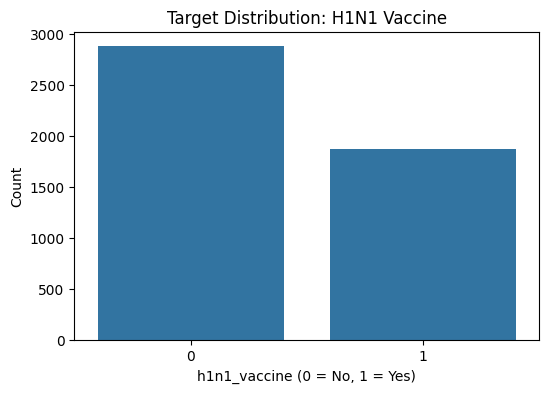

Target percentage:


,percentage
h1n1_vaccine,
0,60.6
1,39.4


In [5]:
TARGET = 'h1n1_vaccine'
ID_COL = 'respondent_id'

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x=TARGET)
plt.title('Target Distribution: H1N1 Vaccine')
plt.xlabel('h1n1_vaccine (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

print('Target percentage:')
display((train_df[TARGET].value_counts(normalize=True)*100).round(2).to_frame('percentage'))

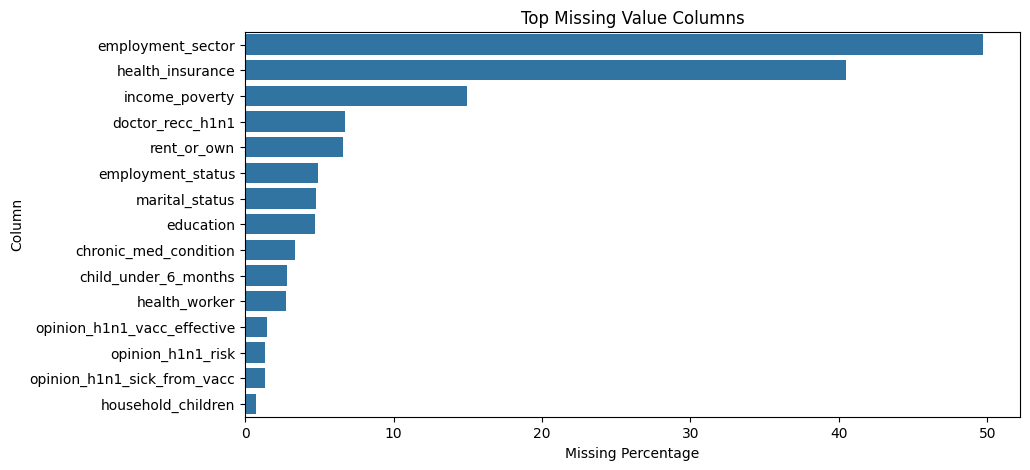

In [6]:
# Missing values bar chart
top_missing = missing_report[missing_report['missing_count'] > 0].head(15)
plt.figure(figsize=(10,5))
sns.barplot(data=top_missing, x='missing_percent', y='column')
plt.title('Top Missing Value Columns')
plt.xlabel('Missing Percentage')
plt.ylabel('Column')
plt.show()

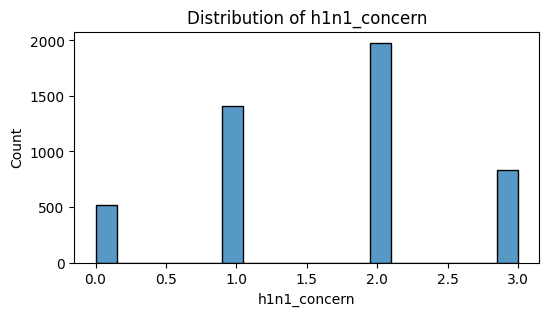

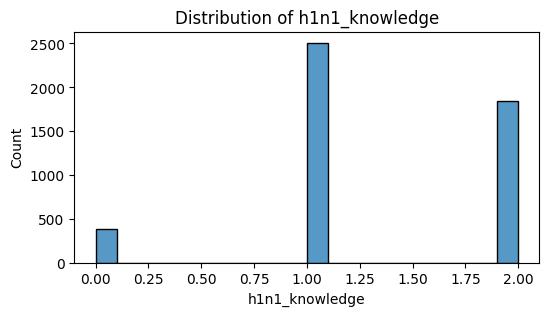

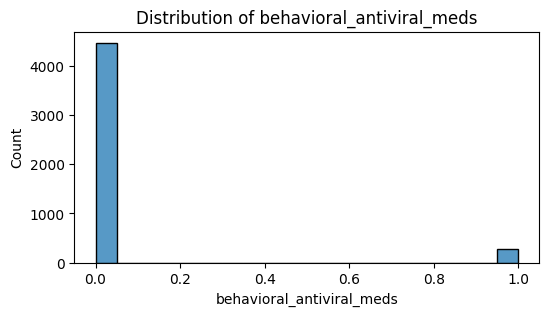

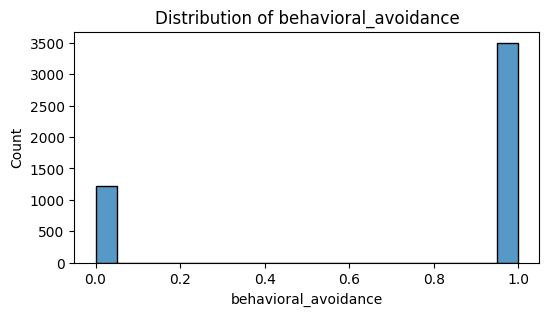

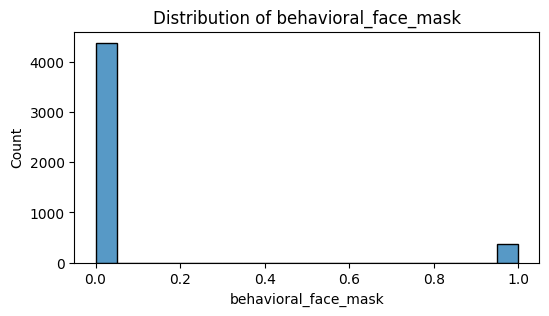

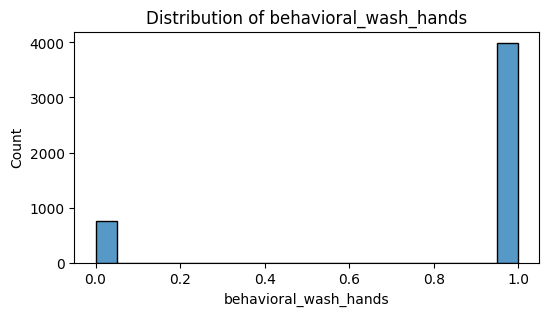

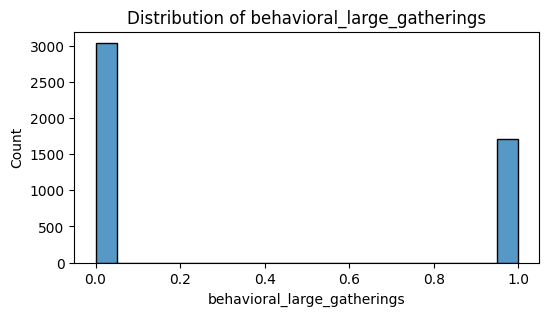

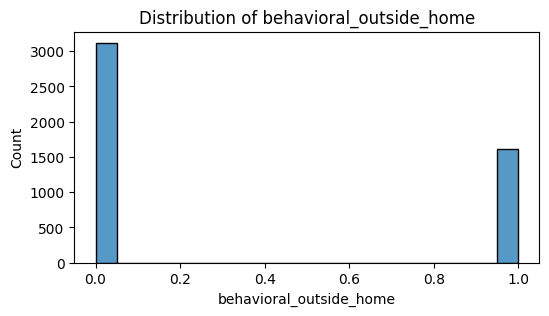

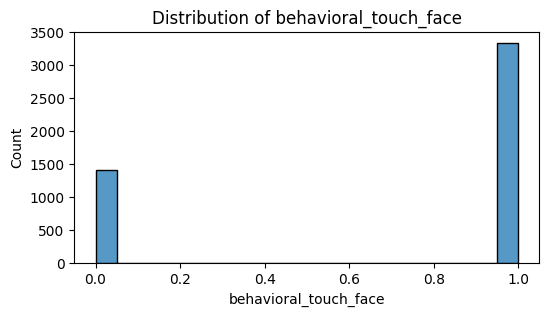

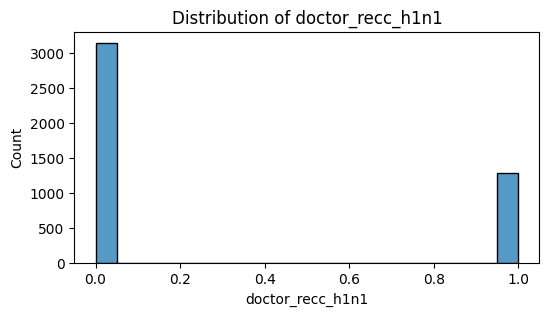

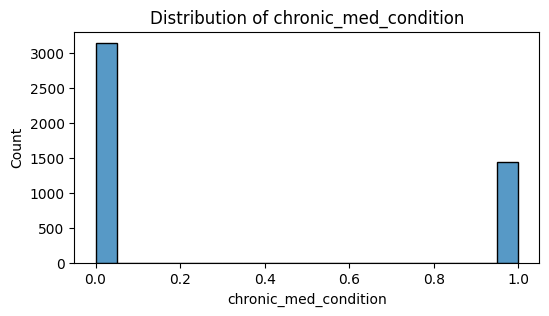

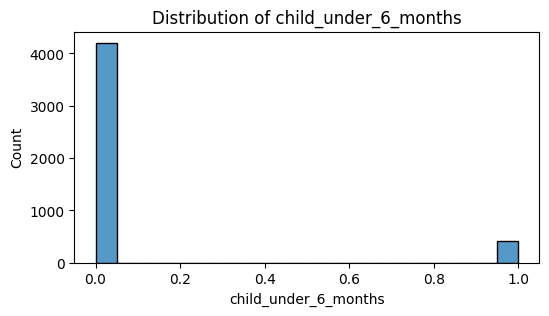

In [7]:
# Numeric feature distributions
numeric_cols = train_df.drop(columns=[TARGET, ID_COL], errors='ignore').select_dtypes(include=['int64','float64']).columns.tolist()

for col in numeric_cols[:12]:
    plt.figure(figsize=(6,3))
    sns.histplot(train_df[col], kde=False, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

,correlation_with_target
h1n1_vaccine,1.000000
doctor_recc_h1n1,0.413874
opinion_h1n1_risk,0.362183
opinion_h1n1_vacc_effective,0.325057
health_worker,0.205428
h1n1_knowledge,0.148766
h1n1_concern,0.143235
health_insurance,0.129246
chronic_med_condition,0.107138
behavioral_touch_face,0.103222


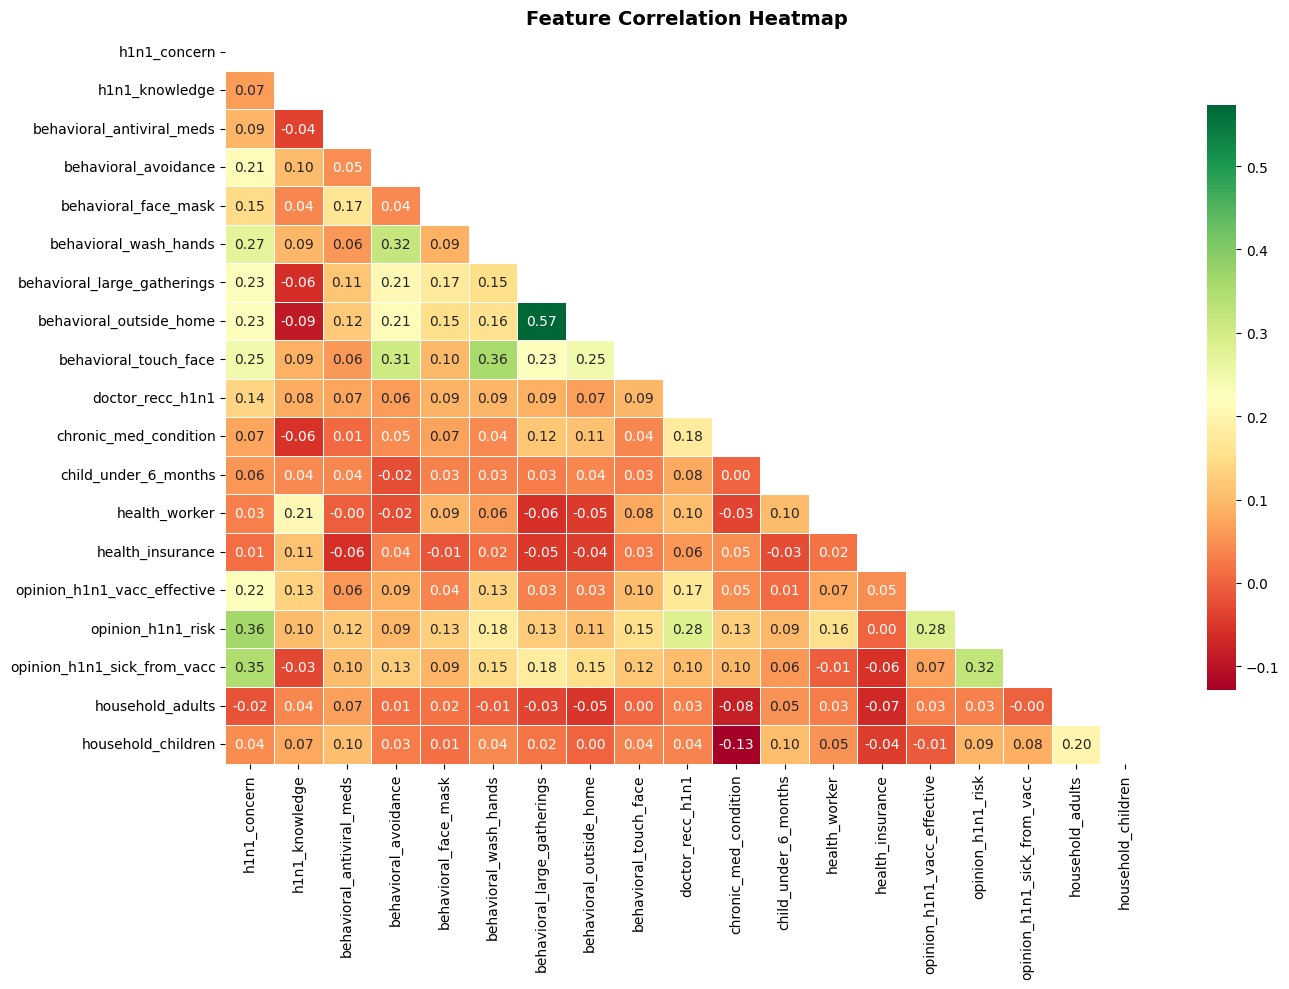

Figure saved: correlation_heatmap.png


In [8]:
# Correlation with target for numeric columns
corr = train_df[numeric_cols + [TARGET]].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
display(corr.to_frame('correlation_with_target'))


plt.figure(figsize=(14, 10))
corr = train_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: correlation_heatmap.png')

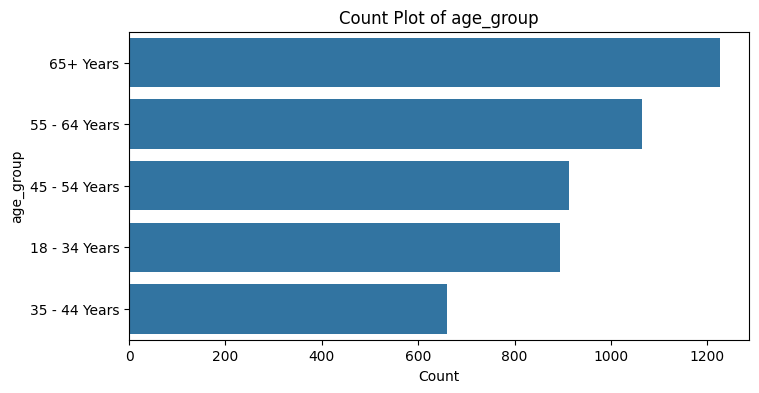

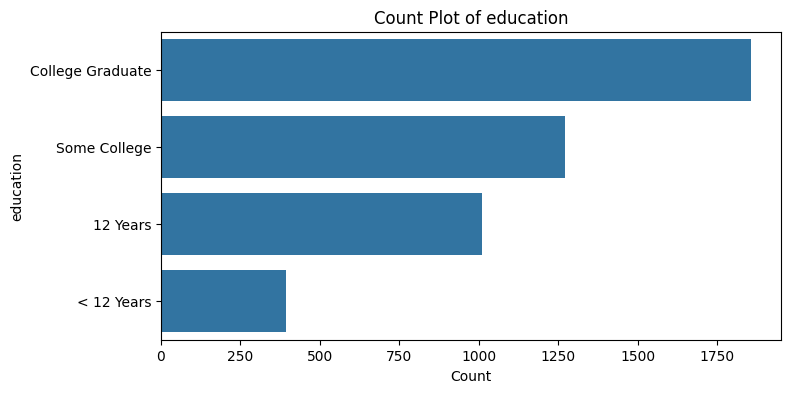

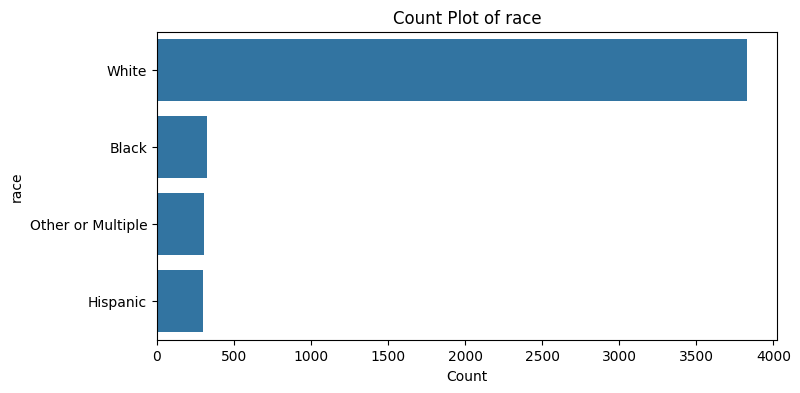

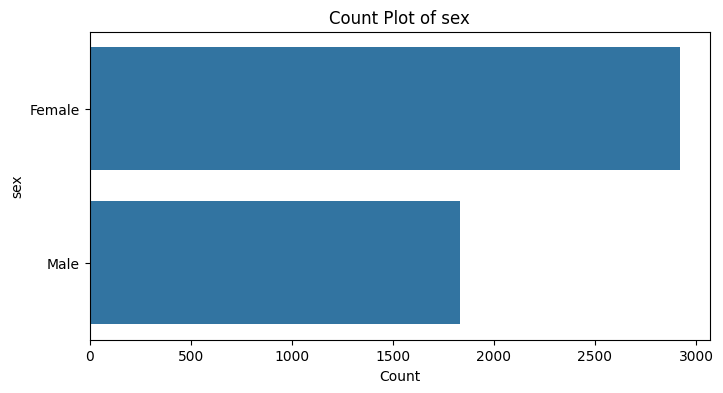

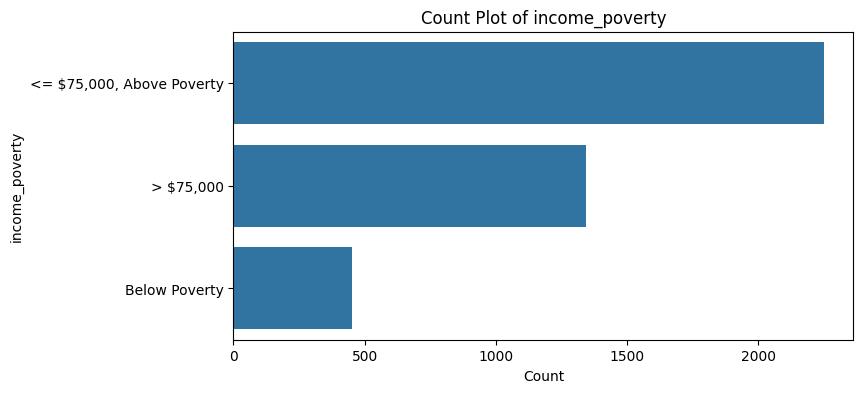

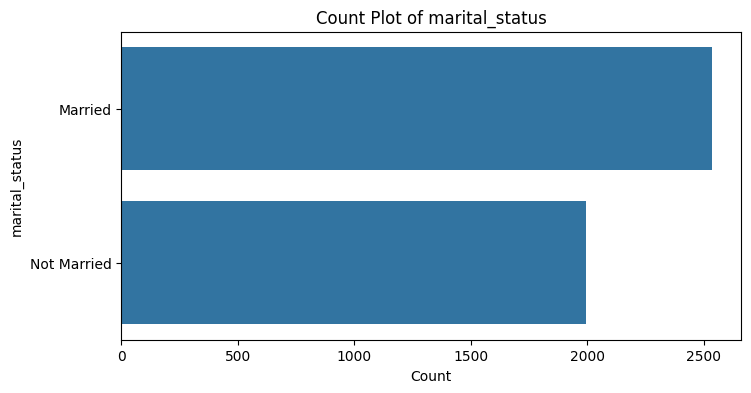

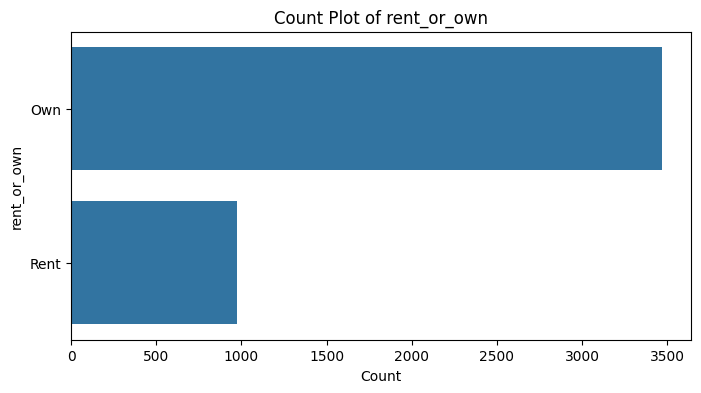

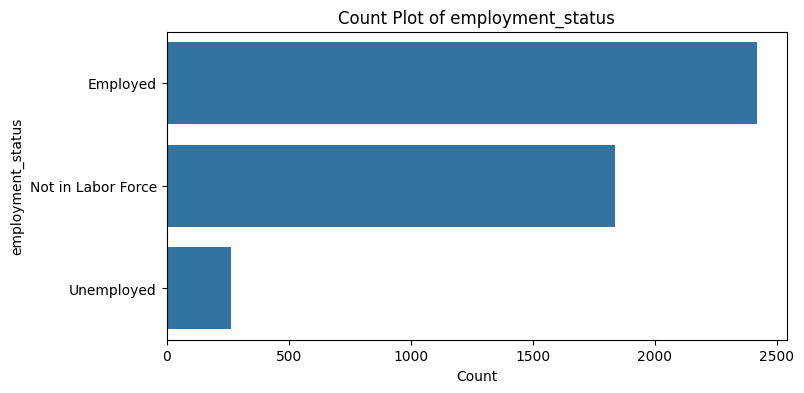

In [9]:
# Categorical feature count plots
categorical_cols = train_df.drop(columns=[TARGET, ID_COL], errors='ignore').select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols[:8]:
    plt.figure(figsize=(8,4))
    sns.countplot(data=train_df, y=col, order=train_df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

## 5. Preprocessing Pipeline

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X = train_df.drop(columns=[TARGET, ID_COL])
y = train_df[TARGET].astype(int)
X_test = test_df.drop(columns=[ID_COL])

num_cols = X.select_dtypes(include=['int64','float64','int32','float32']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print('Numeric columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Train split:', X_train.shape)
print('Validation split:', X_val.shape)

Numeric columns: 19
Categorical columns: 10
Train split: (3804, 29)
Validation split: (952, 29)


## 6. MLP Model with Hyperparameter Tuning


In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import time

param_grid = [
    {'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.001, 'batch_size': 64},
    {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'batch_size': 64},
    {'hidden_layer_sizes': (64, 32), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.0005, 'batch_size': 64},
    {'hidden_layer_sizes': (32,), 'activation': 'tanh', 'alpha': 0.001, 'learning_rate_init': 0.001, 'batch_size': 64},
    {'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 0.01, 'learning_rate_init': 0.0005, 'batch_size': 128}
]

results = []
best_model = None
best_f1 = -1
best_params = None

for i, params in enumerate(param_grid, start=1):
    mlp = MLPClassifier(
        **params,
        solver='adam',
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
        random_state=42
    )

    model_pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', mlp)
    ])

    start = time.time()
    model_pipeline.fit(X_train, y_train)
    fit_seconds = time.time() - start

    y_pred = model_pipeline.predict(X_val)
    y_prob = model_pipeline.predict_proba(X_val)[:, 1]

    row = {
        'trial': i,
        'hidden_layer_sizes': str(params['hidden_layer_sizes']),
        'activation': params['activation'],
        'alpha': params['alpha'],
        'learning_rate_init': params['learning_rate_init'],
        'batch_size': params['batch_size'],
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred),
        'roc_auc': roc_auc_score(y_val, y_prob),
        'fit_seconds': round(fit_seconds, 2)
    }
    results.append(row)

    if row['f1'] > best_f1:
        best_f1 = row['f1']
        best_model = model_pipeline
        best_params = params
        best_y_pred = y_pred
        best_y_prob = y_prob

tuning_results = pd.DataFrame(results).sort_values('f1', ascending=False)
display(tuning_results)
tuning_results.to_csv('mlp_hyperparameter_tuning_results.csv', index=False)

print('Best MLP parameters:')
print(best_params)

,trial,hidden_layer_sizes,activation,alpha,learning_rate_init,batch_size,accuracy,precision,recall,f1,roc_auc,fit_seconds
4,5,"(128, 64)",relu,0.0100,0.0005,128,0.759454,0.733974,0.610667,0.666667,0.813583,1.07
2,3,"(64, 32)",relu,0.0010,0.0005,64,0.748950,0.702381,0.629333,0.663854,0.812072,1.32
1,2,"(64,)",relu,0.0010,0.0010,64,0.746849,0.708075,0.608000,0.654232,0.811083,0.72
0,1,"(32,)",relu,0.0001,0.0010,64,0.743697,0.707937,0.594667,0.646377,0.802995,0.42
3,4,"(32,)",tanh,0.0010,0.0010,64,0.741597,0.703470,0.594667,0.644509,0.808804,0.70


Best MLP parameters:
{'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 0.01, 'learning_rate_init': 0.0005, 'batch_size': 128}


## 7. Final Validation Evaluation

In [12]:
metrics = {
    'model': 'Single MLPClassifier with hyperparameter tuning',
    'validation_accuracy': accuracy_score(y_val, best_y_pred),
    'validation_precision': precision_score(y_val, best_y_pred, zero_division=0),
    'validation_recall': recall_score(y_val, best_y_pred, zero_division=0),
    'validation_f1': f1_score(y_val, best_y_pred),
    'validation_roc_auc': roc_auc_score(y_val, best_y_prob),
    'best_params': str(best_params)
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df)
metrics_df.to_csv('mlp_validation_metrics.csv', index=False)

print(classification_report(y_val, best_y_pred, zero_division=0))

,model,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,best_params
0,Single MLPClassifier with hyperparameter tuning,0.759454,0.733974,0.610667,0.666667,0.813583,"{'hidden_layer_sizes': (128, 64), 'activation'..."


              precision    recall  f1-score   support

           0       0.77      0.86      0.81       577
           1       0.73      0.61      0.67       375

    accuracy                           0.76       952
   macro avg       0.75      0.73      0.74       952
weighted avg       0.76      0.76      0.75       952



,Predicted_0,Predicted_1
Actual_0,494,83
Actual_1,146,229


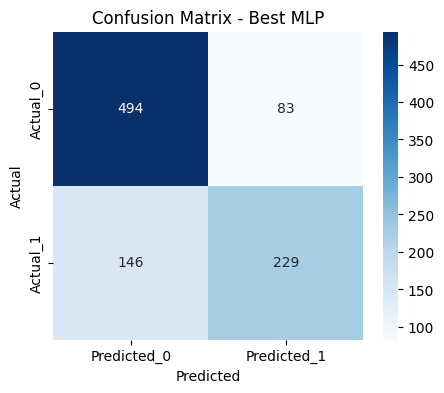

In [13]:
cm = confusion_matrix(y_val, best_y_pred)
cm_df = pd.DataFrame(cm, index=['Actual_0', 'Actual_1'], columns=['Predicted_0', 'Predicted_1'])
display(cm_df)
cm_df.to_csv('mlp_confusion_matrix.csv')

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best MLP')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 9. Explainable AI (XAI) with SHAP

SHAP (SHapley Additive exPlanations) explains each prediction by assigning a contribution value to every feature. We use `KernelExplainer` since our model is wrapped in a sklearn `Pipeline` (black-box compatible).

> **Note:** SHAP's `KernelExplainer` is model-agnostic but slower — we use a background sample of 100 rows and explain 200 validation rows to keep runtime practical.

In [14]:
# Install SHAP if not already available
try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "shap", "-q"])
    import shap
    print("SHAP installed:", shap.__version__)


SHAP version: 0.52.0


In [17]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Prepare data ──────────────────────────────────────────────────────────────
# We explain using the validation split (X_val) so results are on unseen data.
# Subsample for speed: 100 background rows, 200 explanation rows.
np.random.seed(42)
background = X_train.sample(n=100, random_state=42)
X_explain  = X_val.sample(n=200, random_state=42)

# ── Wrapper: pipeline predict_proba for class 1 (vaccinated) ──────────────────
def model_predict(data):
    """Returns probability of class 1 (vaccinated)."""
    # Ensure data is a DataFrame with original column names before passing to the pipeline
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=X_train.columns)
    return best_model.predict_proba(data)[:, 1]

# ── Build KernelExplainer ─────────────────────────────────────────────────────
print("Building SHAP KernelExplainer (this may take ~1–2 minutes)...")
explainer = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(X_explain, nsamples=100)

print("SHAP values computed — shape:", np.array(shap_values).shape)


Building SHAP KernelExplainer (this may take ~1–2 minutes)...


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values computed — shape: (200, 29)


### 9.1 Global Feature Importance — SHAP Summary Plot

The summary (beeswarm) plot shows **which features matter most overall** and in which direction. Each dot is one sample; red = high feature value, blue = low. Horizontal position = SHAP value (impact on model output).

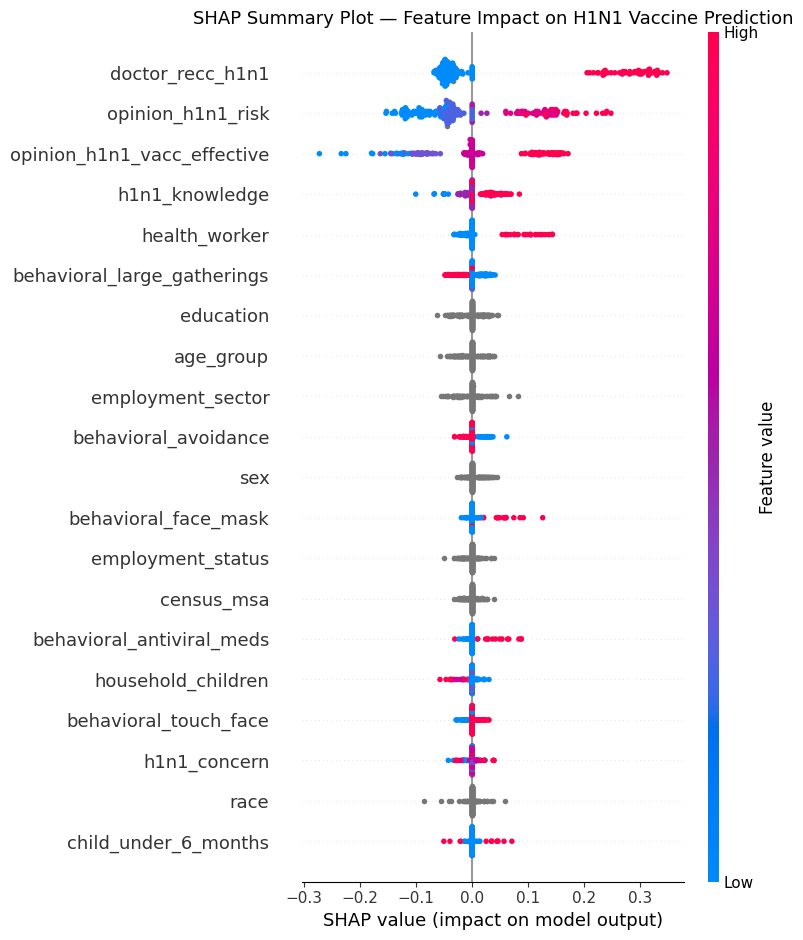

Saved: shap_summary_plot.png


In [18]:
# Summary (beeswarm) plot — global importance
plt.figure()
shap.summary_plot(shap_values, X_explain, show=False)
plt.title("SHAP Summary Plot — Feature Impact on H1N1 Vaccine Prediction", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_summary_plot.png")


### 9.2 Mean Absolute SHAP — Bar Chart

The bar chart ranks features by their **average absolute SHAP value**, giving a clean global importance ranking.

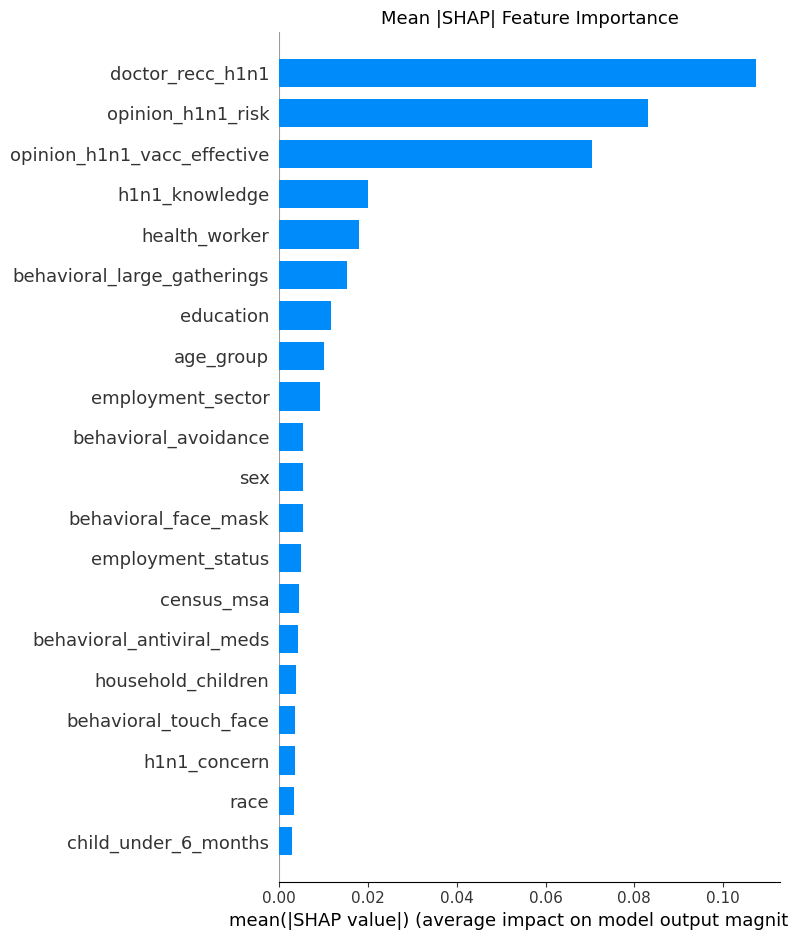

Saved: shap_bar_importance.png


In [19]:
# Bar plot — mean |SHAP| per feature
plt.figure()
shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.title("Mean |SHAP| Feature Importance", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_bar_importance.png")


### 9.3 SHAP Feature Importance Table

Extract the top 15 most important features as a ranked DataFrame — useful for reporting.

In [20]:
# Build a ranked importance table
feature_names = X_val.columns.tolist()
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_df['rank'] = shap_importance_df.index + 1
print("Top 15 features by SHAP importance:")
display(shap_importance_df.head(15))
shap_importance_df.to_csv("shap_feature_importance.csv", index=False)
print("Saved: shap_feature_importance.csv")


Top 15 features by SHAP importance:


,feature,mean_abs_shap,rank
0,doctor_recc_h1n1,0.107423,1
1,opinion_h1n1_risk,0.083152,2
2,opinion_h1n1_vacc_effective,0.070479,3
3,h1n1_knowledge,0.019924,4
4,health_worker,0.018051,5
5,behavioral_large_gatherings,0.015366,6
6,education,0.011658,7
7,age_group,0.010042,8
8,employment_sector,0.009319,9
9,behavioral_avoidance,0.005425,10


Saved: shap_feature_importance.csv


### 9.4 SHAP Dependence Plot — Top Feature

A dependence plot shows **how a single feature affects the prediction** across all samples. The colour represents the most interacting feature (automatically chosen by SHAP).

Plotting dependence for top feature: 'doctor_recc_h1n1'


<Figure size 800x500 with 0 Axes>

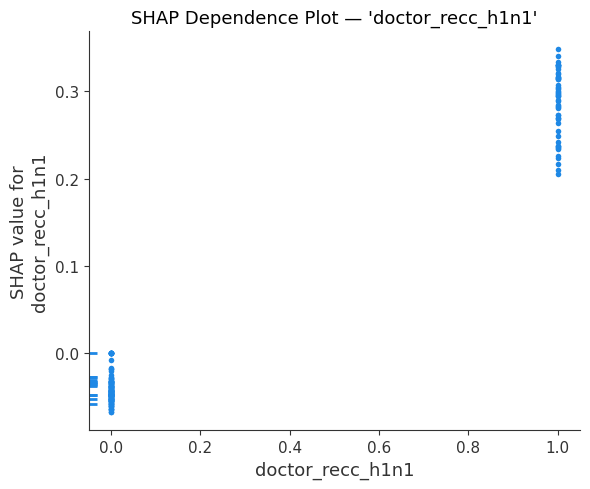

Saved: shap_dependence_top_feature.png


In [22]:
# Dependence plot for the single most important feature
top_feature = shap_importance_df.iloc[0]['feature']
print(f"Plotting dependence for top feature: '{top_feature}'")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    shap_values,
    X_explain,
    interaction_index=None, # Explicitly disable automatic interaction detection
    show=False
)
plt.title(f"SHAP Dependence Plot — '{top_feature}'", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dependence_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: shap_dependence_top_feature.png")


### 9.5 Individual Prediction Explanation — Waterfall Plot

A waterfall plot explains **a single prediction** step by step: it starts from the base value (average model output) and adds each feature's contribution until we reach the final predicted probability.

Explaining sample index 0:
  Predicted probability (vaccinated): 0.0571
  SHAP base value: 0.2978


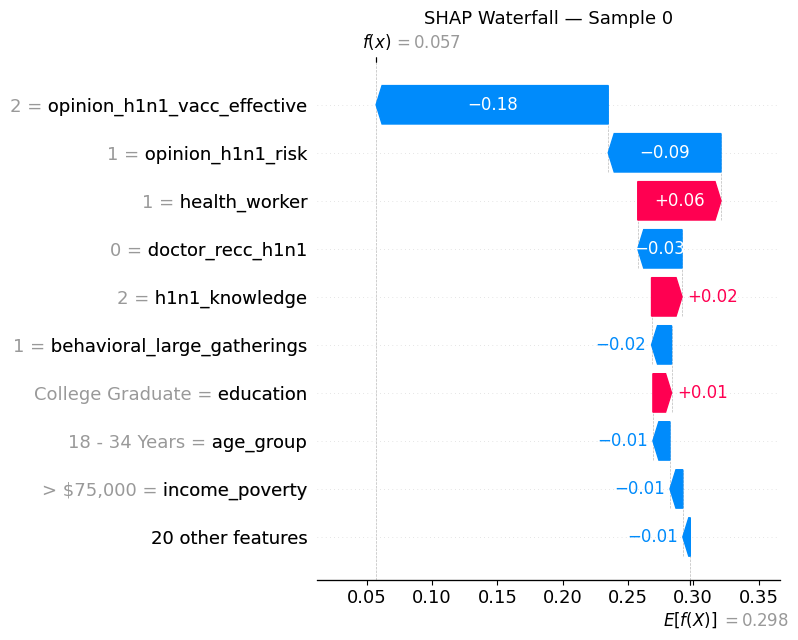

Saved: shap_waterfall_sample0.png


In [23]:
# Waterfall plot for one individual prediction (index 0)
sample_idx = 0
base_value  = explainer.expected_value

print(f"Explaining sample index {sample_idx}:")
print(f"  Predicted probability (vaccinated): {model_predict(X_explain.iloc[[sample_idx]])[0]:.4f}")
print(f"  SHAP base value: {base_value:.4f}")

# Build an Explanation object for the waterfall plot
explanation = shap.Explanation(
    values    = shap_values[sample_idx],
    base_values = base_value,
    data      = X_explain.iloc[sample_idx].values,
    feature_names = feature_names
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Sample {sample_idx}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_waterfall_sample0.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_waterfall_sample0.png")


### 9.6 Summary of Findings

The SHAP analysis provides several key insights:

- **Top predictors**: Features with the highest mean |SHAP| value drive the model's vaccine uptake decisions most strongly. Look at `shap_importance_df` for the ranked list.
- **Direction of effect**: The summary (beeswarm) plot reveals whether high values of a feature push the prediction towards vaccinated (positive SHAP) or not vaccinated (negative SHAP).
- **Interaction effects**: The dependence plot for the top feature shows non-linear relationships and how a second feature moderates its impact.
- **Individual accountability**: The waterfall plot demonstrates the model is explainable at the per-patient level — important for healthcare applications where clinicians need to justify automated predictions.

These explanations directly satisfy the XAI requirement and support trustworthy, auditable decision-making in public health contexts.

## 8. Train Final MLP on Full Training Data and Predict Test Data

In [24]:
final_mlp = MLPClassifier(
    **best_params,
    solver='adam',
    max_iter=80,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42
)

final_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', final_mlp)
])

final_pipeline.fit(X, y)

test_prob = final_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: test_pred,
    'h1n1_vaccine_probability': test_prob
})

display(submission.head())
submission.to_csv('mlp_final_test_predictions.csv', index=False)
print('Saved: mlp_final_test_predictions.csv')

,respondent_id,h1n1_vaccine,h1n1_vaccine_probability
0,4757,0,0.184892
1,4758,0,0.057228
2,4759,0,0.078297
3,4760,0,0.325545
4,4761,0,0.091080


Saved: mlp_final_test_predictions.csv
